In [1]:
from pathlib import Path
import csv
import random
import statistics
import time

import matplotlib.pyplot as plt

from cluster_benchmark_utils import (
    BASE_HTTP_PORT,
    ensure_qad_binary,
    get_read,
    percentile,
    post_write,
    resolve_project_root,
    start_cluster,
    stop_cluster,
)

PROJECT_ROOT = resolve_project_root()
TMP_DIR = PROJECT_ROOT / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)

CLUSTER_SIZES = list(range(1, 11))
EVICTION_ALGORITHMS = ["FIFO", "LRU", "NONE"]

PAYLOAD = b"x" * 1024
PAYLOAD_SIZE = len(PAYLOAD)
STORAGE_SIZE = 1_000_000_000  # very large to avoid eviction

WARMUP_OBJECTS_PER_NODE = 1000
READS_PER_CASE = 2000

RESULTS_CSV = TMP_DIR / "read_benchmark_requests.csv"
RNG = random.Random(42)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results CSV: {RESULTS_CSV}")
print(f"Payload size: {PAYLOAD_SIZE} bytes")
print(f"Storage size: {STORAGE_SIZE} bytes")

Project root: /home/marvin/dev/qad
Results CSV: /home/marvin/dev/qad/tmp/read_benchmark_requests.csv
Payload size: 1024 bytes
Storage size: 1000000000 bytes


In [2]:
def warmup_cluster(
    ports: list[int],
    eviction: str,
    cluster_size: int,
    objects_per_node: int,
    payload: bytes,
    rng: random.Random,
) -> list[str]:
    total_objects = objects_per_node * cluster_size
    keys: list[str] = []

    for i in range(total_objects):
        key = f"warm-{eviction.lower()}-{cluster_size}-{i}-{rng.randrange(10**12)}"
        target_port = rng.choice(ports)
        status, _ = post_write(target_port, key, payload)
        if status == 202:
            keys.append(key)

    # writes are async on the server, allow data propagation before read phase
    time.sleep(1.0)
    return keys

In [3]:
ensure_qad_binary(PROJECT_ROOT)

fieldnames = [
    "timestamp_epoch",
    "eviction",
    "cluster_size",
    "request_index",
    "target_port",
    "key",
    "status",
    "success",
    "latency_ms",
    "response_bytes",
    "payload_bytes",
    "storage_bytes",
    "warmup_keys",
]

total_cases = len(EVICTION_ALGORITHMS) * len(CLUSTER_SIZES)
case_num = 0

with RESULTS_CSV.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()

    for eviction in EVICTION_ALGORITHMS:
        for size in CLUSTER_SIZES:
            case_num += 1
            print(
                f"[{case_num}/{total_cases}] eviction={eviction}, cluster_size={size} ..."
            )

            proc = None
            latencies_ms: list[float] = []
            read_failures = 0

            try:
                proc = start_cluster(
                    project_root=PROJECT_ROOT,
                    node_count=size,
                    eviction=eviction,
                    storage_size=STORAGE_SIZE,
                )

                ports = [BASE_HTTP_PORT + i for i in range(size)]
                warmup_keys = warmup_cluster(
                    ports=ports,
                    eviction=eviction,
                    cluster_size=size,
                    objects_per_node=WARMUP_OBJECTS_PER_NODE,
                    payload=PAYLOAD,
                    rng=RNG,
                )

                if not warmup_keys:
                    print("  warmup failed: no keys written successfully")
                    continue

                for i in range(READS_PER_CASE):
                    key = RNG.choice(warmup_keys)
                    target_port = RNG.choice(ports)

                    status, latency_ms, response_bytes = get_read(target_port, key)
                    ok = status == 200

                    writer.writerow(
                        {
                            "timestamp_epoch": f"{time.time():.6f}",
                            "eviction": eviction,
                            "cluster_size": size,
                            "request_index": i,
                            "target_port": target_port,
                            "key": key,
                            "status": "" if status is None else status,
                            "success": int(ok),
                            "latency_ms": f"{latency_ms:.6f}",
                            "response_bytes": response_bytes,
                            "payload_bytes": PAYLOAD_SIZE,
                            "storage_bytes": STORAGE_SIZE,
                            "warmup_keys": len(warmup_keys),
                        }
                    )

                    if ok:
                        latencies_ms.append(latency_ms)
                    else:
                        read_failures += 1

                f.flush()

                success_count = len(latencies_ms)
                mean_ms = (
                    statistics.mean(latencies_ms) if latencies_ms else float("nan")
                )
                p95_ms = percentile(latencies_ms, 0.95)

                print(
                    f"  warmup_keys={len(warmup_keys)}, "
                    f"read_success={success_count}/{READS_PER_CASE}, "
                    f"fail={read_failures}, mean={mean_ms:.2f} ms, p95={p95_ms:.2f} ms"
                )
            finally:
                stop_cluster(proc)

print("\nDone.")
print(f"Per-request read results written to: {RESULTS_CSV}")
RESULTS_CSV

[1/30] eviction=FIFO, cluster_size=1 ...
  warmup_keys=1000, read_success=2000/2000, fail=0, mean=0.66 ms, p95=1.22 ms
[2/30] eviction=FIFO, cluster_size=2 ...
  warmup_keys=2000, read_success=2000/2000, fail=0, mean=1.28 ms, p95=1.89 ms
[3/30] eviction=FIFO, cluster_size=3 ...
  warmup_keys=3000, read_success=2000/2000, fail=0, mean=1.32 ms, p95=1.80 ms
[4/30] eviction=FIFO, cluster_size=4 ...
  warmup_keys=4000, read_success=2000/2000, fail=0, mean=1.48 ms, p95=2.07 ms
[5/30] eviction=FIFO, cluster_size=5 ...
  warmup_keys=5000, read_success=2000/2000, fail=0, mean=1.45 ms, p95=1.91 ms
[6/30] eviction=FIFO, cluster_size=6 ...
  warmup_keys=6000, read_success=2000/2000, fail=0, mean=1.61 ms, p95=2.40 ms
[7/30] eviction=FIFO, cluster_size=7 ...
  warmup_keys=7000, read_success=2000/2000, fail=0, mean=1.52 ms, p95=1.98 ms
[8/30] eviction=FIFO, cluster_size=8 ...
  warmup_keys=8000, read_success=2000/2000, fail=0, mean=1.56 ms, p95=2.02 ms
[9/30] eviction=FIFO, cluster_size=9 ...
  warmu

PosixPath('/home/marvin/dev/qad/tmp/read_benchmark_requests.csv')

eviction size      n    mean_ms     p50_ms     p95_ms     p99_ms
----------------------------------------------------------------
FIFO      1   2000      0.662      0.561      1.216      1.552
FIFO      2   2000      1.276      1.261      1.888      2.197
FIFO      3   2000      1.321      1.369      1.797      2.051
FIFO      4   2000      1.477      1.492      2.069      2.483
FIFO      5   2000      1.450      1.482      1.907      2.254
FIFO      6   2000      1.611      1.579      2.405      2.766
FIFO      7   2000      1.519      1.532      1.979      2.321
FIFO      8   2000      1.563      1.560      2.016      2.395
FIFO      9   2000      1.648      1.586      2.392      3.180
FIFO     10   2000      1.586      1.566      2.070      2.526
LRU       1   2000      0.706      0.669      1.103      1.303
LRU       2   2000      1.299      1.280      1.906      2.359
LRU       3   2000      1.434      1.462      2.121      2.722
LRU       4   2000      1.508      1.507      2.214

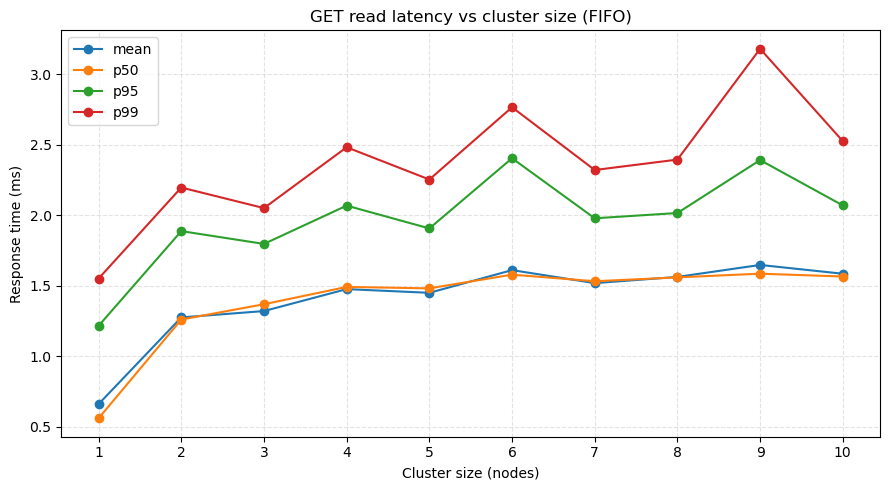

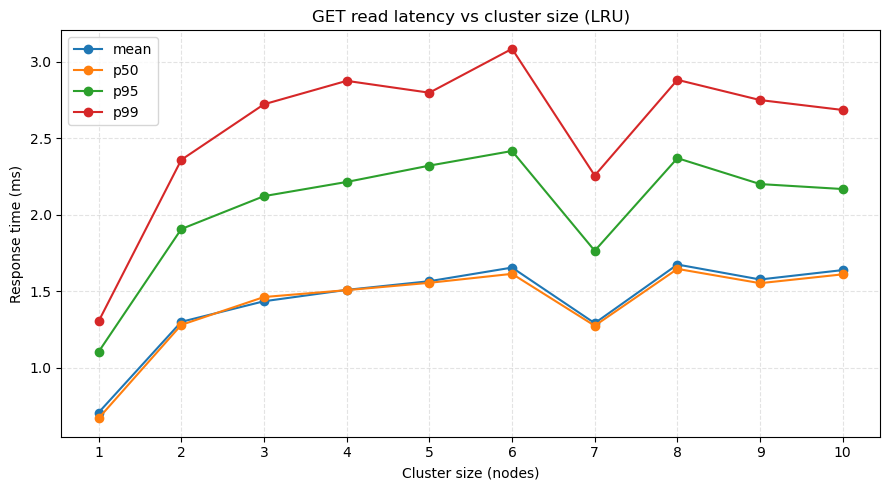

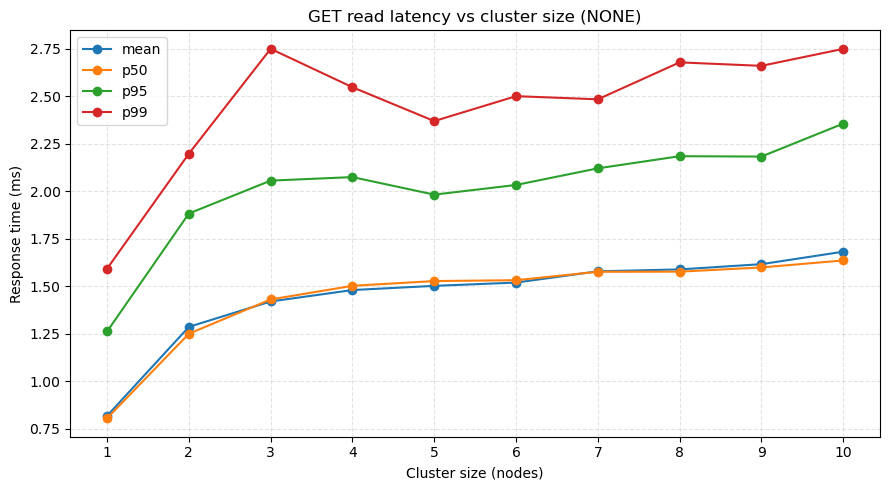

In [4]:
from collections import defaultdict

agg: dict[tuple[str, int], list[float]] = defaultdict(list)

with RESULTS_CSV.open("r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            eviction = row["eviction"]
            size = int(row["cluster_size"])
            status = int(row["status"]) if row["status"] else None
            latency_ms = float(row["latency_ms"])
        except (KeyError, ValueError):
            continue

        if status == 200:
            agg[(eviction, size)].append(latency_ms)

summary_rows: list[dict] = []
for eviction in EVICTION_ALGORITHMS:
    for size in CLUSTER_SIZES:
        values = agg.get((eviction, size), [])
        summary_rows.append(
            {
                "eviction": eviction,
                "cluster_size": size,
                "count": len(values),
                "mean_ms": statistics.mean(values) if values else float("nan"),
                "p50_ms": percentile(values, 0.50),
                "p95_ms": percentile(values, 0.95),
                "p99_ms": percentile(values, 0.99),
            }
        )

header = (
    f"{'eviction':<6} {'size':>4} {'n':>6} {'mean_ms':>10} "
    f"{'p50_ms':>10} {'p95_ms':>10} {'p99_ms':>10}"
)
print(header)
print("-" * len(header))
for r in summary_rows:
    print(
        f"{r['eviction']:<6} {r['cluster_size']:>4} {r['count']:>6} "
        f"{r['mean_ms']:>10.3f} {r['p50_ms']:>10.3f} "
        f"{r['p95_ms']:>10.3f} {r['p99_ms']:>10.3f}"
    )

for eviction in EVICTION_ALGORITHMS:
    rows = [r for r in summary_rows if r["eviction"] == eviction]
    rows.sort(key=lambda x: x["cluster_size"])

    xs = [r["cluster_size"] for r in rows]
    mean_line = [r["mean_ms"] for r in rows]
    p50_line = [r["p50_ms"] for r in rows]
    p95_line = [r["p95_ms"] for r in rows]
    p99_line = [r["p99_ms"] for r in rows]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(xs, mean_line, marker="o", label="mean")
    ax.plot(xs, p50_line, marker="o", label="p50")
    ax.plot(xs, p95_line, marker="o", label="p95")
    ax.plot(xs, p99_line, marker="o", label="p99")

    ax.set_title(f"GET read latency vs cluster size ({eviction})")
    ax.set_xlabel("Cluster size (nodes)")
    ax.set_ylabel("Response time (ms)")
    ax.set_xticks(CLUSTER_SIZES)
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()
    plt.tight_layout()
    plt.show()